## Imports

In [1]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

### Plan: Given runs, balls, fours and sixes, calculate st. rate, balls/boundary, boundary percent parallely
- Strike rate
- Balls per boundary
- boundary percent  
  
  
**Note: Non-LLM workflow**

In [4]:
# create State schema
class BatsmanStats(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    # calculated
    strike_rate: float
    ball_p_boundary: float
    boundary_percent: float
    summary: str

In [15]:
# create functions for nodes
def strike_rate(state:BatsmanStats)->BatsmanStats:
    runs = state['runs']
    balls = state['balls']
    strike_rate = round(100*runs/ balls,2)
    return {'strike_rate': strike_rate}

def ball_p_boundary(state:BatsmanStats)->BatsmanStats:
    total_boundary = state['fours']+state['fours']
    balls = state['balls']
    ball_p_boundary = round(balls/total_boundary,2)
    return {'ball_p_boundary': ball_p_boundary}

def boundary_percent(state:BatsmanStats)->BatsmanStats:
    boundary_runs = 4*state['fours']+6*state['fours']
    runs = state['runs']
    boundary_percent = round(100*boundary_runs/runs,2)
    return {'boundary_percent': boundary_percent}

def summary(state:BatsmanStats)->BatsmanStats:
    summary = (f"\nStrike Rate = {state['strike_rate']}\n"
                f"\nBalls per boundary = {state['ball_p_boundary']}\n"
                f"\nBoundary Percent = {state['boundary_percent']}")
    return {'summary':summary}

## State Workflow

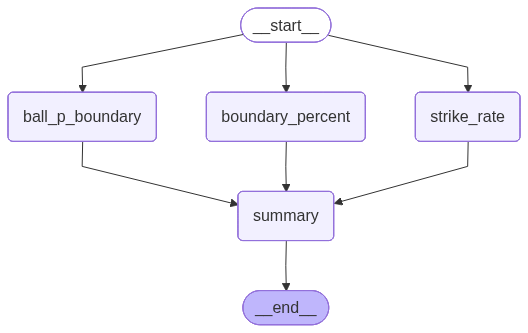

In [16]:
## initialize state
graph = StateGraph(BatsmanStats)

# add nodes
graph.add_node("strike_rate", strike_rate)
graph.add_node("ball_p_boundary", ball_p_boundary)
graph.add_node("boundary_percent", boundary_percent)
graph.add_node("summary", summary)

# add edges
graph.add_edge(START,"strike_rate")
graph.add_edge(START,"ball_p_boundary")
graph.add_edge(START,"boundary_percent")

graph.add_edge("strike_rate","summary")
graph.add_edge("ball_p_boundary","summary")
graph.add_edge("boundary_percent","summary")

graph.add_edge("summary", END)

# compile graph
workflow = graph.compile()

## Visualizing the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## Workflow Usage

In [17]:
initial_state = {'runs':30, 'balls':20,'fours':2, 'sixes':2}

final_state = workflow.invoke(initial_state)

In [18]:
print(final_state['summary'])


Strike Rate = 150.0

Balls per boundary = 5.0

Boundary Percent = 66.67
